# Per-Attention-Head Sycophancy Probes

Train an independent linear probe on each attention head in Qwen2.5-7B-Instruct
to classify sycophantic vs non-sycophantic behaviour.

**Input**: A CSV from `evaluationtriggers.py` with `prompt` and `category` columns.

**Method**: Hook into each layer's `self_attn.o_proj` pre-hook to capture per-head
output vectors *before* the output projection mixes heads. Reshape the input to
`o_proj` from `(batch, seq, hidden_dim)` → `(batch, seq, num_heads, head_dim)`,
extract at position −1, train `nn.Linear(head_dim, 1)` per (layer, head).

**Output**: A `(num_layers × num_heads)` accuracy heatmap + CSV of all results.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.notebook import tqdm

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
CSV_PATH = "mmlu_severity_results_None_detailed.csv"  # change to your file
MODEL_NAME = "google/gemma-3-12b-it"
EXTRACT_BATCH_SIZE = 8
PROBE_EPOCHS = 20
PROBE_LR = 1e-3
PROBE_BATCH_SIZE = 64
TRAIN_FRAC = 0.6
VAL_FRAC = 0.2
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from huggingface_hub import login

In [ ]:
TOKEN = ''

login(token=TOKEN)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, device_map="auto", torch_dtype=torch.bfloat16
)
model.eval()

# Qwen3-8B-IT
#NUM_LAYERS = model.config.text_config.num_hidden_layers
# NUM_HEADS = model.config.text_config.num_attention_heads
# HIDDEN_DIM = model.config.text_config.hidden_size
# HEAD_DIM = getattr(model.config, "head_dim", HIDDEN_DIM // NUM_HEADS)

# print(f"Layers: {NUM_LAYERS}, Heads: {NUM_HEADS}, Head dim: {HEAD_DIM}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/916 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Gemma3ForConditionalGeneration(
  (model): Gemma3Model(
    (vision_tower): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(4096, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              )
              (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwi

In [ ]:
NUM_LAYERS = model.config.text_config.num_hidden_layers
NUM_HEADS = model.config.text_config.num_attention_heads
HIDDEN_DIM = model.config.text_config.hidden_size
HEAD_DIM = model.config.text_config.head_dim

print(f"Layers: {NUM_LAYERS}, Heads: {NUM_HEADS}, Head dim: {HEAD_DIM}")

Layers: 48, Heads: 16, Head dim: 256


In [ ]:
# ── Load CSV and prepare data ─────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df = df[df["category"].isin(["sycophancy", "correct"])].reset_index(drop=True)

labels = torch.tensor(
    [1 if c == "sycophancy" else 0 for c in df["category"]],
    dtype=torch.float32,
)
prompts = df["prompt"].tolist()

n_syc = int(labels.sum().item())
print(f"Total: {len(prompts)}  |  Sycophantic: {n_syc}  |  Non-sycophantic: {len(prompts) - n_syc}")

Total: 929  |  Sycophantic: 423  |  Non-sycophantic: 506


In [ ]:
# ── Train / val / test split ──────────────────────────────────────
indices = list(range(len(prompts)))
random.shuffle(indices)

n = len(indices)
t1 = int(n * TRAIN_FRAC)
t2 = int(n * (TRAIN_FRAC + VAL_FRAC))

train_idx = indices[:t1]
val_idx = indices[t1:t2]
test_idx = indices[t2:]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 557, Val: 186, Test: 186


language_model.layers.0.self_attn.o_proj
language_model.layers.1.self_attn.o_proj
language_model.layers.2.self_attn.o_proj
language_model.layers.3.self_attn.o_proj
language_model.layers.4.self_attn.o_proj
language_model.layers.5.self_attn.o_proj
language_model.layers.6.self_attn.o_proj
language_model.layers.7.self_attn.o_proj
language_model.layers.8.self_attn.o_proj
language_model.layers.9.self_attn.o_proj
language_model.layers.10.self_attn.o_proj
language_model.layers.11.self_attn.o_proj
language_model.layers.12.self_attn.o_proj
language_model.layers.13.self_attn.o_proj
language_model.layers.14.self_attn.o_proj
language_model.layers.15.self_attn.o_proj
language_model.layers.16.self_attn.o_proj
language_model.layers.17.self_attn.o_proj
language_model.layers.18.self_attn.o_proj
language_model.layers.19.self_attn.o_proj
language_model.layers.20.self_attn.o_proj
language_model.layers.21.self_attn.o_proj
language_model.layers.22.self_attn.o_proj
language_model.layers.23.self_attn.o_proj
la

In [ ]:
# ── Per-head activation extraction ────────────────────────────────
#
# Hook into self_attn.o_proj with a pre-hook.  The input to o_proj
# is (batch, seq, num_heads * head_dim) — the concatenated head
# outputs BEFORE the output projection mixes them.
# Reshape → (batch, seq, num_heads, head_dim), take position -1.

def extract_per_head_activations(prompt_indices):
    """
    Extract per-head activations for a subset of prompts.

    Returns
    -------
    activations : dict  (layer_idx -> Tensor of shape (N, num_heads, head_dim))
    split_labels : Tensor of shape (N,)
    """
    accum = {i: [] for i in range(NUM_LAYERS)}
    _buf = {}

    def make_hook(layer_idx):
        def hook_fn(module, args):
            # args[0]: (batch, seq, hidden_dim)
            x = args[0][:, -1, :]                          # (batch, hidden_dim)
            x = x.view(x.shape[0], NUM_HEADS, HEAD_DIM)    # (batch, num_heads, head_dim)
            _buf[layer_idx] = x.detach().float().cpu()
        return hook_fn

    # Register fresh hooks
    # hooks = []
    # for i in range(NUM_LAYERS):
    #     h = model.model.layers[i].self_attn.o_proj.register_forward_pre_hook(make_hook(i))
    #     hooks.append(h)

    hooks = []
    i = 0
    for name, module in model.model.named_modules():
      if "self_attn.o_proj" in name:
        h = module.register_forward_pre_hook(make_hook(i))
        i += 1
        hooks.append(h)

    try:
        for start in tqdm(range(0, len(prompt_indices), EXTRACT_BATCH_SIZE),
                          desc="Extracting"):
            batch_idx = prompt_indices[start : start + EXTRACT_BATCH_SIZE]
            batch_prompts = [prompts[j] for j in batch_idx]

            texts = [
                tokenizer.apply_chat_template(
                    [{"role": "user", "content": p}],
                    tokenize=False,
                    add_generation_prompt=True,
                )
                for p in batch_prompts
            ]

            inputs = tokenizer(
                texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=2048,
                add_special_tokens=False,
            ).to(model.device)

            _buf.clear()
            with torch.no_grad():
                model(**inputs)

            for i in range(NUM_LAYERS):
                accum[i].append(_buf[i])
    finally:
        for h in hooks:
            h.remove()

    activations = {i: torch.cat(accum[i], dim=0) for i in range(NUM_LAYERS)}
    split_labels = labels[prompt_indices]
    return activations, split_labels

In [ ]:
# ── Extract activations for each split ────────────────────────────
print("Extracting train activations...")
train_acts, train_labels = extract_per_head_activations(train_idx)

print("Extracting val activations...")
val_acts, val_labels = extract_per_head_activations(val_idx)

print("Extracting test activations...")
test_acts, test_labels = extract_per_head_activations(test_idx)

print(f"Train acts shape per layer: {train_acts[0].shape}")  # (N_train, num_heads, head_dim)

Extracting train activations...


Extracting:   0%|          | 0/70 [00:00<?, ?it/s]

Extracting val activations...


Extracting:   0%|          | 0/24 [00:00<?, ?it/s]

Extracting test activations...


Extracting:   0%|          | 0/24 [00:00<?, ?it/s]

Train acts shape per layer: torch.Size([557, 16, 256])


In [ ]:
# ── Z-score normalize (train stats only) ──────────────────────────
norm_stats = {}  # (layer, head) -> {mean, std}

for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        x = train_acts[layer][:, head, :]           # (N_train, head_dim)
        mean = x.mean(dim=0)
        std = x.std(dim=0).clamp(min=1e-8)
        norm_stats[(layer, head)] = {"mean": mean, "std": std}

        # Normalize in-place for each split
        train_acts[layer][:, head, :] = (train_acts[layer][:, head, :] - mean) / std
        val_acts[layer][:, head, :]   = (val_acts[layer][:, head, :]   - mean) / std
        test_acts[layer][:, head, :]  = (test_acts[layer][:, head, :]  - mean) / std

print("Normalization done (train stats only).")

Normalization done (train stats only).


In [ ]:
# ── Probe training (PyTorch only) ─────────────────────────────────

def train_probe(train_X, train_y, val_X, val_y):
    """Train nn.Linear(head_dim, 1), select best epoch by val acc."""
    probe = nn.Linear(train_X.shape[1], 1, bias=True).to(DEVICE)
    opt = torch.optim.Adam(probe.parameters(), lr=PROBE_LR)
    loss_fn = nn.BCEWithLogitsLoss()

    ds = TensorDataset(train_X, train_y)
    loader = DataLoader(ds, batch_size=PROBE_BATCH_SIZE, shuffle=True)

    best_val_acc = -1.0
    best_state = {k: v.clone() for k, v in probe.state_dict().items()}

    val_X_dev = val_X.to(DEVICE)
    val_y_dev = val_y.to(DEVICE)

    for _ in range(PROBE_EPOCHS):
        probe.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = probe(xb).squeeze(-1)
            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

        probe.eval()
        with torch.no_grad():
            val_acc = (
                ((probe(val_X_dev).squeeze(-1) > 0).float() == val_y_dev)
                .float().mean().item()
            )
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in probe.state_dict().items()}

    probe.load_state_dict(best_state)
    return probe, best_val_acc


def evaluate_probe(probe, test_X, test_y):
    """Evaluate once on held-out test set."""
    probe.eval()
    with torch.no_grad():
        preds = (probe(test_X.to(DEVICE)).squeeze(-1) > 0).float()
        return (preds == test_y.to(DEVICE)).float().mean().item()

In [ ]:
# ── Train one probe per (layer, head) ─────────────────────────────
val_acc_grid = torch.zeros(NUM_LAYERS, NUM_HEADS)
test_acc_grid = torch.zeros(NUM_LAYERS, NUM_HEADS)

for layer in tqdm(range(NUM_LAYERS), desc="Layers"):
    for head in range(NUM_HEADS):
        trX = train_acts[layer][:, head, :]   # (N_train, head_dim)
        vaX = val_acts[layer][:, head, :]
        teX = test_acts[layer][:, head, :]

        probe, val_acc = train_probe(trX, train_labels, vaX, val_labels)
        test_acc = evaluate_probe(probe, teX, test_labels)

        val_acc_grid[layer, head] = val_acc
        test_acc_grid[layer, head] = test_acc

    # Print progress per layer
    best_head = test_acc_grid[layer].argmax().item()
    print(
        f"  Layer {layer:2d}: best head {best_head} "
        f"(val={val_acc_grid[layer, best_head]:.4f}, "
        f"test={test_acc_grid[layer, best_head]:.4f})"
    )

Layers:   0%|          | 0/48 [00:00<?, ?it/s]

  Layer  0: best head 1 (val=0.6720, test=0.7151)
  Layer  1: best head 2 (val=0.6129, test=0.6989)
  Layer  2: best head 7 (val=0.6667, test=0.7204)
  Layer  3: best head 4 (val=0.7151, test=0.6989)
  Layer  4: best head 7 (val=0.7097, test=0.7312)
  Layer  5: best head 8 (val=0.7366, test=0.7473)
  Layer  6: best head 7 (val=0.7419, test=0.7527)
  Layer  7: best head 0 (val=0.7204, test=0.7419)
  Layer  8: best head 2 (val=0.7312, test=0.7527)
  Layer  9: best head 14 (val=0.7204, test=0.7634)
  Layer 10: best head 9 (val=0.7312, test=0.7581)
  Layer 11: best head 4 (val=0.6935, test=0.7634)
  Layer 12: best head 7 (val=0.7043, test=0.7527)
  Layer 13: best head 5 (val=0.7204, test=0.7527)
  Layer 14: best head 7 (val=0.7581, test=0.7688)
  Layer 15: best head 5 (val=0.7473, test=0.7742)
  Layer 16: best head 8 (val=0.7312, test=0.7634)
  Layer 17: best head 13 (val=0.7151, test=0.7849)
  Layer 18: best head 2 (val=0.7903, test=0.7903)
  Layer 19: best head 8 (val=0.7473, test=0.7742

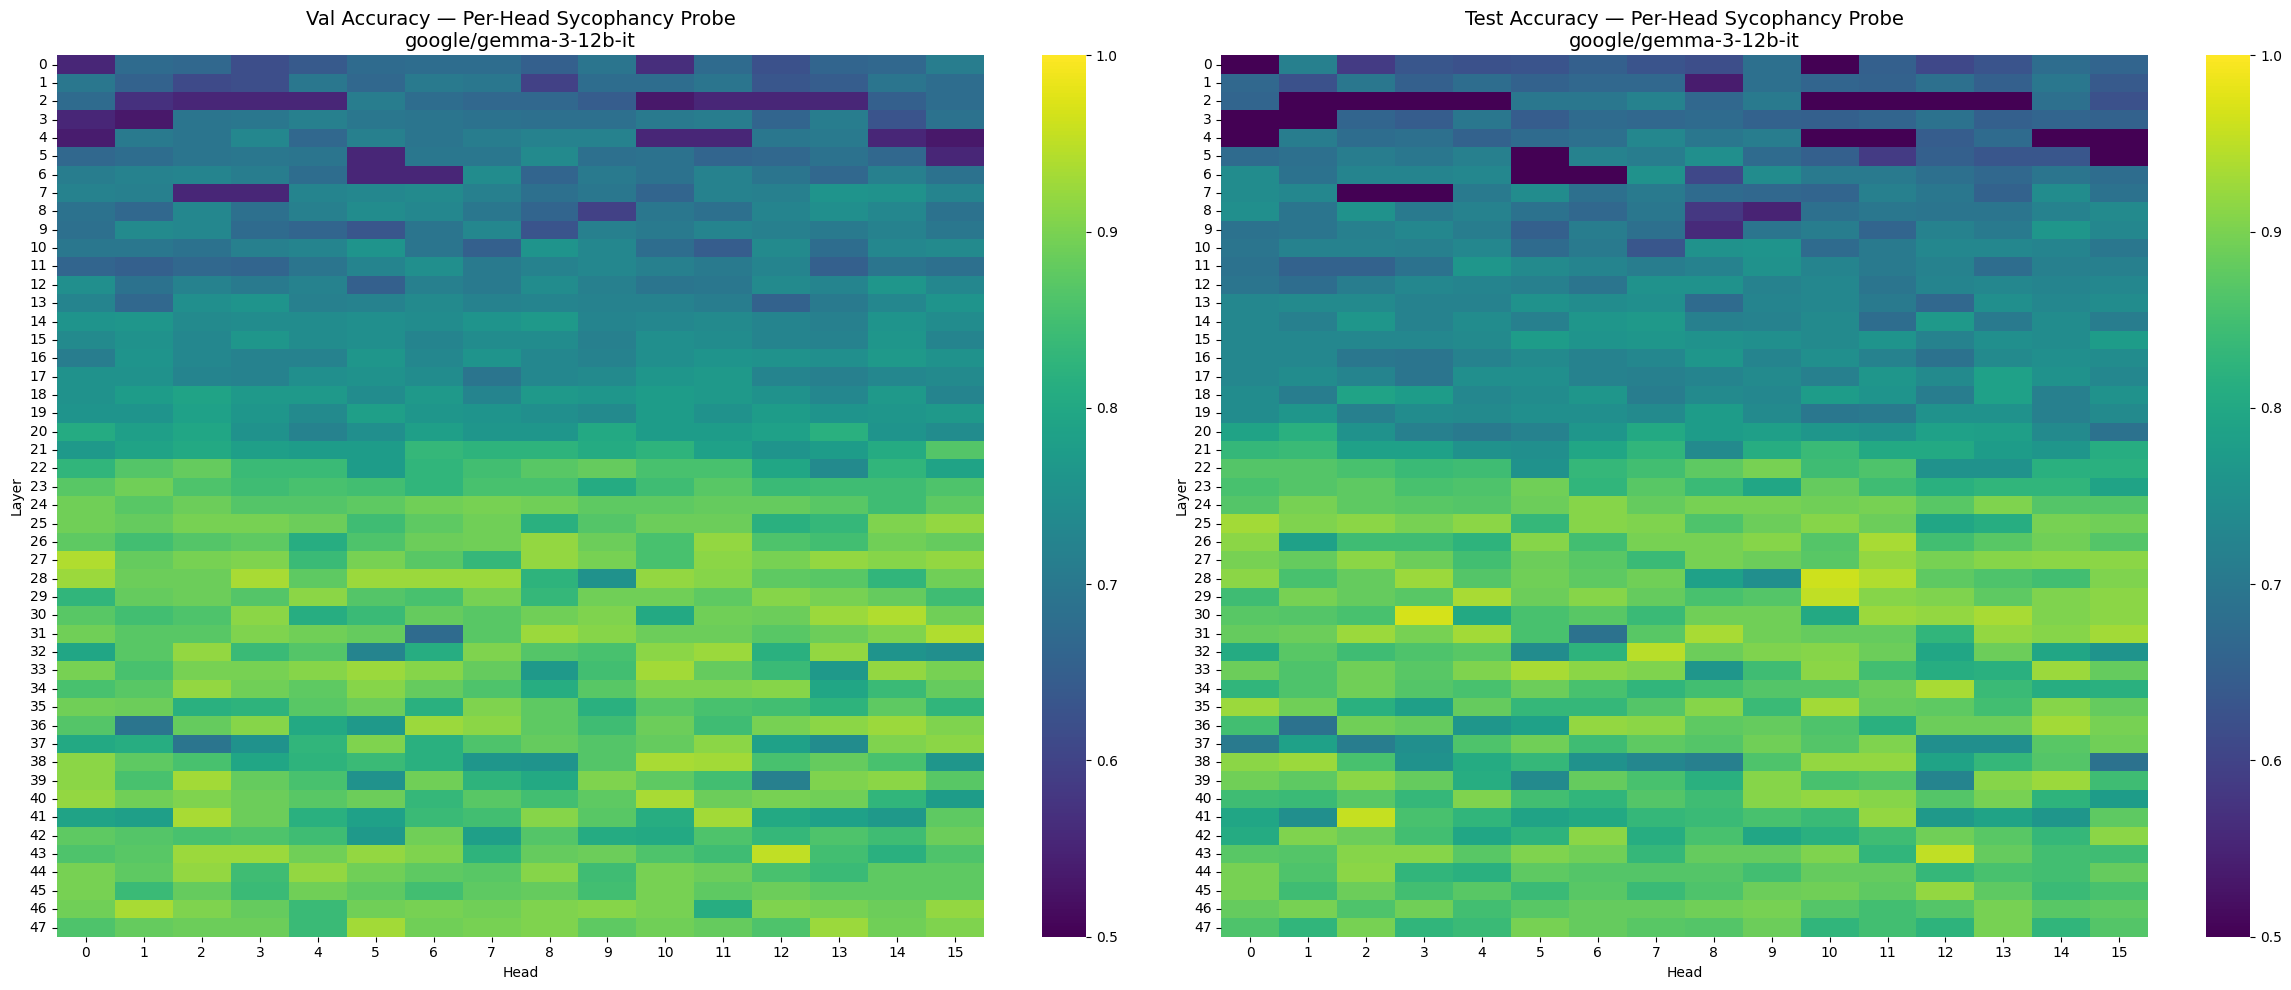

Saved per_head_probe_heatmap.png


In [ ]:
# ── Heatmap: test accuracy per (layer, head) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, grid, title in [
    (axes[0], val_acc_grid, "Val Accuracy"),
    (axes[1], test_acc_grid, "Test Accuracy"),
]:
    sns.heatmap(
        grid.numpy(),
        ax=ax,
        cmap="viridis",
        vmin=0.5,
        vmax=1.0,
        annot=False,
        xticklabels=range(NUM_HEADS),
        yticklabels=range(NUM_LAYERS),
    )
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    ax.set_title(f"{title} — Per-Head Sycophancy Probe\n{MODEL_NAME}", fontsize=14)

plt.tight_layout()
plt.savefig("per_head_probe_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved per_head_probe_heatmap.png")

In [ ]:
# ── Top-k heads by test accuracy ─────────────────────────────────
TOP_K = 20

flat = test_acc_grid.flatten()
topk_vals, topk_flat_idx = flat.topk(TOP_K)

rows = []
print(f"\nTop-{TOP_K} heads by test accuracy:")
print(f"{'Rank':>4}  {'Layer':>5}  {'Head':>4}  {'Val Acc':>8}  {'Test Acc':>8}")
print("-" * 40)

for rank, (val, flat_i) in enumerate(zip(topk_vals, topk_flat_idx), 1):
    layer = flat_i.item() // NUM_HEADS
    head = flat_i.item() % NUM_HEADS
    v_acc = val_acc_grid[layer, head].item()
    t_acc = val.item()
    print(f"{rank:4d}  {layer:5d}  {head:4d}  {v_acc:8.4f}  {t_acc:8.4f}")
    rows.append({"layer": layer, "head": head, "val_acc": v_acc, "test_acc": t_acc})


Top-20 heads by test accuracy:
Rank  Layer  Head   Val Acc  Test Acc
----------------------------------------
   1     30     3    0.9140    0.9677
   2     28    10    0.9194    0.9624
   3     41     2    0.9355    0.9570
   4     43    12    0.9516    0.9516
   5     29    10    0.8925    0.9516
   6     32     7    0.9032    0.9462
   7     28    11    0.9086    0.9409
   8     26    11    0.9194    0.9355
   9     29     4    0.9140    0.9355
  10     30    13    0.9247    0.9355
  11     34    12    0.9086    0.9355
  12     31     8    0.9247    0.9355
  13     33     5    0.9247    0.9355
  14     36    14    0.9247    0.9301
  15     31    15    0.9409    0.9301
  16     25     0    0.8925    0.9301
  17     35    10    0.8710    0.9301
  18     31     4    0.8925    0.9301
  19     28     3    0.9355    0.9247
  20     39    14    0.9140    0.9247


In [ ]:
# ── Save full results to CSV ──────────────────────────────────────
all_rows = []
for layer in range(NUM_LAYERS):
    for head in range(NUM_HEADS):
        all_rows.append({
            "layer": layer,
            "head": head,
            "val_acc": val_acc_grid[layer, head].item(),
            "test_acc": test_acc_grid[layer, head].item(),
        })

results_df = pd.DataFrame(all_rows)
out_csv = f"per_head_probe_results_{MODEL_NAME.split('/')[-1]}.csv"
results_df.to_csv(out_csv, index=False)
print(f"Full results ({len(all_rows)} probes) saved to {out_csv}")

Full results (768 probes) saved to per_head_probe_results_gemma-3-12b-it.csv


In [ ]:
# ── Per-layer summary ─────────────────────────────────────────────
print(f"\n{'Layer':>5}  {'Mean Test':>9}  {'Max Test':>9}  {'Best Head':>9}")
print("-" * 40)
for layer in range(NUM_LAYERS):
    row = test_acc_grid[layer]
    print(
        f"{layer:5d}  {row.mean():9.4f}  {row.max():9.4f}  {row.argmax().item():9d}"
    )


Layer  Mean Test   Max Test  Best Head
----------------------------------------
    0     0.6210     0.7151          1
    1     0.6573     0.6989          2
    2     0.5817     0.7204          7
    3     0.6374     0.6989          4
    4     0.6153     0.7312          7
    5     0.6552     0.7473          8
    6     0.6771     0.7527          7
    7     0.6747     0.7419          0
    8     0.6892     0.7527          2
    9     0.6952     0.7634         14
   10     0.7103     0.7581          9
   11     0.7097     0.7634          4
   12     0.7194     0.7527          7
   13     0.7255     0.7527          5
   14     0.7308     0.7688          7
   15     0.7460     0.7742          5
   16     0.7272     0.7634          8
   17     0.7356     0.7849         13
   18     0.7453     0.7903          2
   19     0.7376     0.7742          8
   20     0.7577     0.8172          1
   21     0.7940     0.8387          1
   22     0.8327     0.8978          9
   23     0.8454     0